In [1]:
import numpy as np
import pandas as pd
from scipy.optimize import minimize

try:
    from vnstock import Quote
except:
    from vnstock_data import Quote


# 1. THIẾT LẬP THÔNG TIN

tickers = ['VNM', 'HPG', 'FPT']

start_date = '2020-01-01'
end_date = '2022-12-31'

position = 3_000_000_000
confidence_level = 0.99
alpha = 1 - confidence_level



# 2. HÀM LẤY GIÁ ĐÓNG CỬA

def get_close_price(symbol, start_date, end_date):
    for source in ['KBS', 'VCI']:
        try:
            quote = Quote(symbol=symbol, source=source)
            df = quote.history(start=start_date, end=end_date, interval='1D')

            df.columns = df.columns.str.lower()

            if 'time' in df.columns:
                df['time'] = pd.to_datetime(df['time'])
                df = df.set_index('time')
            elif 'date' in df.columns:
                df['date'] = pd.to_datetime(df['date'])
                df = df.set_index('date')

            if 'close' not in df.columns:
                raise ValueError(f"{symbol} không có cột close")

            close = df['close'].copy()
            close.name = symbol

            
            return close

        except Exception as e:
            print(f"Lỗi {symbol} với nguồn {source}: {e}")

    raise ValueError(f"Không lấy được dữ liệu cho mã {symbol}")



# 3. LẤY DỮ LIỆU GIÁ

prices = pd.DataFrame()

for ticker in tickers:
    prices[ticker] = get_close_price(ticker, start_date, end_date)

prices = prices.sort_index().dropna()




# 4. TÍNH LỢI SUẤT NGÀY

returns = prices.pct_change().dropna()




# 5. TÍNH TỶ TRỌNG TỐI THIỂU PHƯƠNG SAI

cov_matrix_daily = returns.cov()

SCALE = 1_000_000

def portfolio_variance_scaled(weights, cov_matrix):
    return SCALE * (weights.T @ cov_matrix @ weights)

n_assets = len(tickers)

constraints = {
    'type': 'eq',
    'fun': lambda weights: np.sum(weights) - 1
}

bounds = tuple((0, 1) for _ in range(n_assets))

initial_guesses = [
    np.array([1/3, 1/3, 1/3]),
    np.array([0.8, 0.1, 0.1]),
    np.array([0.1, 0.8, 0.1]),
    np.array([0.1, 0.1, 0.8]),
    np.array([0.5, 0.3, 0.2]),
    np.array([0.2, 0.5, 0.3]),
    np.array([0.3, 0.2, 0.5])
]

best_result = None

for guess in initial_guesses:
    result = minimize(
        portfolio_variance_scaled,
        guess,
        args=(cov_matrix_daily,),
        method='SLSQP',
        bounds=bounds,
        constraints=constraints,
        options={
            'ftol': 1e-12,
            'maxiter': 1000
        }
    )

    if result.success:
        if best_result is None or result.fun < best_result.fun:
            best_result = result

if best_result is None:
    raise ValueError("Không tối ưu được danh mục. Cần kiểm tra lại dữ liệu.")

optimal_weights = best_result.x
optimal_weights = optimal_weights / optimal_weights.sum()

portfolio_var_daily = optimal_weights.T @ cov_matrix_daily @ optimal_weights
portfolio_vol_daily = np.sqrt(portfolio_var_daily)

portfolio_var_annual = portfolio_var_daily * 252
portfolio_vol_annual = portfolio_vol_daily * np.sqrt(252)

allocation = optimal_weights * position

result_table = pd.DataFrame({
    'Stock': tickers,
    'Weight': optimal_weights,
    'Weight (%)': optimal_weights * 100,
    'Allocation (VND)': allocation
})

pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', '{:,.6f}'.format)

print("\nBEST MINIMUM VARIANCE PORTFOLIO")
print(f"Daily Volatility: {portfolio_vol_daily:.4%}")
print(f"Annual Variance: {portfolio_var_annual:.8f}")

print("\nTỷ trọng tối ưu:")
print(result_table.to_string(index=False))




📦 **Vnstock 4.0.4 is available**
Current: 4.0.2 (Python 3.13)
Update: `pip install vnstock --upgrade`
Release: https://vnstocks.com/docs/tai-lieu/lich-su-phien-ban

📦 **Vnai 2.4.9 is available**
Current: 2.4.8 (Python 3.13)
Update: `pip install vnai --upgrade`
Release: https://pypi.org/project/vnai/#history


BEST MINIMUM VARIANCE PORTFOLIO
Daily Volatility: 1.5167%
Annual Variance: 0.05796795

Tỷ trọng tối ưu:
Stock   Weight  Weight (%)     Allocation (VND)
  VNM 0.589496   58.949595 1,768,487,859.635942
  HPG 0.103987   10.398663   311,959,889.744014
  FPT 0.306517   30.651742   919,552,250.620043


HISTORICAL VAR

In [2]:
# Tính Historical VaR danh mục và VaR riêng lẻ từng cổ phiếu

import numpy as np
import pandas as pd

try:
    from vnstock import Quote
except:
    from vnstock_data import Quote


# 1. THIẾT LẬP

tickers = ['VNM', 'HPG', 'FPT']

# Tỷ trọng tối thiểu phương sai đã tính được
weights = np.array([0.58926361, 0.10390407, 0.30683231])
weights = weights / weights.sum()

position = 3_000_000_000  # Tổng giá trị đầu tư: 3 tỷ đồng
confidence_level = 0.99

start_date = '2020-01-01'
end_date = '2022-12-31'


# 2. HÀM LẤY GIÁ ĐÓNG CỬA

def get_close_price(symbol, start_date, end_date):
    for source in ['KBS', 'VCI']:
        try:
            quote = Quote(symbol=symbol, source=source)
            df = quote.history(start=start_date, end=end_date, interval='1D')

            df.columns = df.columns.str.lower()

            if 'time' in df.columns:
                df['time'] = pd.to_datetime(df['time'])
                df = df.set_index('time')
            elif 'date' in df.columns:
                df['date'] = pd.to_datetime(df['date'])
                df = df.set_index('date')

            close = df['close'].copy()
            close.name = symbol
            return close

        except Exception:
            pass

    raise ValueError(f"Không lấy được dữ liệu cho mã {symbol}")


# 3. TẢI DỮ LIỆU GIÁ

prices = pd.DataFrame()

for ticker in tickers:
    prices[ticker] = get_close_price(ticker, start_date, end_date)

prices = prices.sort_index().dropna()


# 4. TÍNH LỢI SUẤT NGÀY

data = prices.pct_change().dropna()


# 5. HISTORICAL VaR DANH MỤC
# Theo công thức:
# n = len(ret)
# t = int((1 - confidence) * n)
# VaR = position * sorted_ret[t]

port_ret = data.dot(weights)
sorted_port_ret = np.sort(port_ret)
n_obs = len(sorted_port_ret)
t = int((1 - confidence_level) * n_obs)
var_ret_port = sorted_port_ret[t]

VaR_port = position * var_ret_port

print("\n[VaR DANH MỤC - PHƯƠNG PHÁP LỊCH SỬ]")
print(f"Số quan sát: {n_obs}")
print(f"Mức tin cậy: {confidence_level:.0%}")
print(f"Vị trí đuôi trái t: {t}")
print(f"Lợi suất VaR danh mục: {var_ret_port:.4%}")
print(f"Holding = {position:,.0f} VND")
print(f"Portfolio VaR (99%) = {abs(VaR_port):,.0f} VND")


# 6. VaR RIÊNG LẺ TỪNG MÃ

print("\n[VaR RIÊNG LẺ - PHƯƠNG PHÁP LỊCH SỬ]")

VaR_sum = 0

for i, ticker in enumerate(tickers):
    sorted_r = np.sort(data[ticker])

    var_r = sorted_r[t]

    sub_pos = position * weights[i]

    VaR_i = sub_pos * var_r
    VaR_sum += abs(VaR_i)

    print(
        f"{ticker} | "
        f"Tỷ trọng = {weights[i]:.4%} | "
        f"Holding = {sub_pos:,.0f} VND | "
        f"VaR = {abs(VaR_i):,.0f} VND"
    )


# 7. TỔNG VaR RIÊNG LẺ

print(f"\nTổng VaR riêng lẻ cộng từng mã = {VaR_sum:,.0f} VND")
print(f"VaR danh mục = {abs(VaR_port):,.0f} VND")


[VaR DANH MỤC - PHƯƠNG PHÁP LỊCH SỬ]
Số quan sát: 750
Mức tin cậy: 99%
Vị trí đuôi trái t: 7
Lợi suất VaR danh mục: -4.7394%
Holding = 3,000,000,000 VND
Portfolio VaR (99%) = 142,182,959 VND

[VaR RIÊNG LẺ - PHƯƠNG PHÁP LỊCH SỬ]
VNM | Tỷ trọng = 58.9264% | Holding = 1,767,790,848 VND | VaR = 87,355,623 VND
HPG | Tỷ trọng = 10.3904% | Holding = 311,712,213 VND | VaR = 21,367,369 VND
FPT | Tỷ trọng = 30.6832% | Holding = 920,496,939 VND | VaR = 57,060,903 VND

Tổng VaR riêng lẻ cộng từng mã = 165,783,895 VND
VaR danh mục = 142,182,959 VND


In [3]:


# 8. EXPECTED SHORTFALL DANH MỤC
# Theo công thức: ES = position * average(Ri | Ri < Rcutoff)

tail_returns_port = sorted_port_ret[:t]
ES_port = position * tail_returns_port.mean()

print("\n[EXPECTED SHORTFALL DANH MỤC - PHƯƠNG PHÁP LỊCH SỬ]")
print(f"Số quan sát trong vùng xấu nhất: {t}")
print(f"Lợi suất trung bình vùng xấu nhất: {tail_returns_port.mean():.4%}")
print(f"Expected Shortfall danh mục (99%) = {abs(ES_port):,.0f} VND")



# 9. EXPECTED SHORTFALL RIÊNG LẺ TỪNG MÃ

print("\n[EXPECTED SHORTFALL RIÊNG LẺ - PHƯƠNG PHÁP LỊCH SỬ]")

ES_sum = 0

for i, ticker in enumerate(tickers):
    sorted_r = np.sort(data[ticker])

    tail_returns_i = sorted_r[:t]

    sub_pos = position * weights[i]

    ES_i = sub_pos * tail_returns_i.mean()
    ES_sum += abs(ES_i)

    print(
        f"{ticker} | "
        f"Tỷ trọng = {weights[i]:.4%} | "
        f"Holding = {sub_pos:,.0f} VND | "
        f"ES = {abs(ES_i):,.0f} VND"
    )



# 10. TỔNG HỢP KẾT QUẢ

print("\n[TỔNG HỢP KẾT QUẢ]")
print(f"VaR danh mục (99%) = {abs(VaR_port):,.0f} VND")
print(f"Expected Shortfall danh mục (99%) = {abs(ES_port):,.0f} VND")
print(f"Tổng VaR riêng lẻ cộng từng mã = {VaR_sum:,.0f} VND")
print(f"Tổng ES riêng lẻ cộng từng mã = {ES_sum:,.0f} VND")


[EXPECTED SHORTFALL DANH MỤC - PHƯƠNG PHÁP LỊCH SỬ]
Số quan sát trong vùng xấu nhất: 7
Lợi suất trung bình vùng xấu nhất: -6.2177%
Expected Shortfall danh mục (99%) = 186,529,675 VND

[EXPECTED SHORTFALL RIÊNG LẺ - PHƯƠNG PHÁP LỊCH SỬ]
VNM | Tỷ trọng = 58.9264% | Holding = 1,767,790,848 VND | ES = 116,623,555 VND
HPG | Tỷ trọng = 10.3904% | Holding = 311,712,213 VND | ES = 21,618,361 VND
FPT | Tỷ trọng = 30.6832% | Holding = 920,496,939 VND | ES = 62,192,848 VND

[TỔNG HỢP KẾT QUẢ]
VaR danh mục (99%) = 142,182,959 VND
Expected Shortfall danh mục (99%) = 186,529,675 VND
Tổng VaR riêng lẻ cộng từng mã = 165,783,895 VND
Tổng ES riêng lẻ cộng từng mã = 200,434,764 VND


In [4]:

# BACKTESTING HISTORICAL VaR DANH MỤC
# Rolling window theo công thức sorted_ret[t]

import numpy as np
import pandas as pd
from scipy.stats import chi2

rolling_window = 300
alpha = 1 - confidence_level

var_forecasts = []
realized_returns = []
violations = []
dates = []

for i in range(rolling_window, len(port_ret)):
    # Dùng 300 ngày trước để tính VaR
    estimation_window = port_ret.iloc[i - rolling_window:i]

    # Sắp xếp lợi suất từ thấp đến cao
    sorted_window = np.sort(estimation_window)

    # Theo công thức: t = int((1 - confidence) * n)
    n_window = len(sorted_window)
    t_bt = int(alpha * n_window)

    # VaR return theo công thức: sorted_ret[t]
    var_return_t = sorted_window[t_bt]

    # Lợi suất thực tế của ngày kế tiếp
    realized_return_t = port_ret.iloc[i]

    # Ngoại lệ xảy ra khi lợi suất thực tế thấp hơn hoặc bằng VaR dự báo
    violation_t = realized_return_t <= var_return_t

    dates.append(port_ret.index[i])
    var_forecasts.append(var_return_t)
    realized_returns.append(realized_return_t)
    violations.append(violation_t)

backtest_df = pd.DataFrame({
    'Realized_Return': realized_returns,
    'VaR_Return': var_forecasts,
    'Violation': violations
}, index=dates)


# KẾT QUẢ BACKTESTING

T = len(backtest_df)
x = backtest_df['Violation'].sum()

expected_ratio = alpha
actual_ratio = x / T
expected_violations = T * expected_ratio

print("\n[BACKTESTING HISTORICAL VaR DANH MỤC - ROLLING WINDOW]")
print(f"Số ngày kiểm định: {T}")
print(f"Cửa sổ ước lượng VaR: {rolling_window} ngày")
print(f"Mức tin cậy: {confidence_level:.0%}")
print(f"Tỷ lệ ngoại lệ kỳ vọng: {expected_ratio:.2%}")
print(f"Số ngoại lệ kỳ vọng: {expected_violations:.2f}")
print(f"Số ngoại lệ thực tế: {x}")
print(f"Tỷ lệ ngoại lệ thực tế: {actual_ratio:.4%}")


# KUPIEC UC TEST

if x == 0 or x == T:
    print("\n[KUPIEC UC TEST]")
    print("Không thể tính Kupiec UC test do số ngoại lệ bằng 0 hoặc bằng tổng số quan sát.")
else:
    p = expected_ratio
    phat = actual_ratio

    LR_uc = 2 * (
        x * np.log(phat / p) +
        (T - x) * np.log((1 - phat) / (1 - p))
    )

    p_value = 1 - chi2.cdf(LR_uc, df=1)

    print("\n[KUPIEC UC TEST]")
    print(f"LR_uc = {LR_uc:.4f}")
    print(f"p-value = {p_value:.4f}")

    if p_value > 0.01:
        print("Kết luận: Không bác bỏ mô hình VaR. Tỷ lệ ngoại lệ thực tế phù hợp với mức kỳ vọng.")
    else:
        print("Kết luận: Bác bỏ mô hình VaR. Tỷ lệ ngoại lệ thực tế khác đáng kể so với mức kỳ vọng.")

        
# CHRISTOFFERSEN INDEPENDENCE TEST
# Kiểm định xem các ngoại lệ VaR có độc lập theo thời gian hay không

import numpy as np
from scipy.stats import chi2

# Chuyển chuỗi ngoại lệ thành 0 và 1
hits = backtest_df['Violation'].astype(int).values

# Trạng thái ngoại lệ ngày t-1 và ngày t
hit_lag = hits[:-1]
hit_now = hits[1:]

# Đếm số lần chuyển trạng thái
n00 = np.sum((hit_lag == 0) & (hit_now == 0))
n01 = np.sum((hit_lag == 0) & (hit_now == 1))
n10 = np.sum((hit_lag == 1) & (hit_now == 0))
n11 = np.sum((hit_lag == 1) & (hit_now == 1))

def log_term(count, prob):
    if count == 0:
        return 0
    if prob <= 0:
        return -np.inf
    return count * np.log(prob)

# Xác suất ngoại lệ chung
pi = (n01 + n11) / (n00 + n01 + n10 + n11)

# Xác suất ngoại lệ có điều kiện
pi0 = n01 / (n00 + n01) if (n00 + n01) > 0 else 0
pi1 = n11 / (n10 + n11) if (n10 + n11) > 0 else 0

# Log-likelihood khi ngoại lệ độc lập
LL_independent = (
    log_term(n00 + n10, 1 - pi) +
    log_term(n01 + n11, pi)
)

# Log-likelihood khi ngoại lệ phụ thuộc trạng thái trước đó
LL_dependent = (
    log_term(n00, 1 - pi0) +
    log_term(n01, pi0) +
    log_term(n10, 1 - pi1) +
    log_term(n11, pi1)
)

# Thống kê kiểm định Christoffersen Independence
LR_ind = -2 * (LL_independent - LL_dependent)
p_value_ind = 1 - chi2.cdf(LR_ind, df=1)

print("[CHRISTOFFERSEN INDEPENDENCE TEST]")
print("n00 =", n00)
print("n01 =", n01)
print("n10 =", n10)
print("n11 =", n11)
print("LR_ind =", round(LR_ind, 4))
print("p-value =", round(p_value_ind, 4))

if p_value_ind > 0.01:
    print("Kết luận: Không bác bỏ giả thuyết ngoại lệ VaR độc lập theo thời gian.")
else:
    print("Kết luận: Bác bỏ giả thuyết ngoại lệ VaR độc lập. Ngoại lệ có thể bị dồn cụm.")







[BACKTESTING HISTORICAL VaR DANH MỤC - ROLLING WINDOW]
Số ngày kiểm định: 450
Cửa sổ ước lượng VaR: 300 ngày
Mức tin cậy: 99%
Tỷ lệ ngoại lệ kỳ vọng: 1.00%
Số ngoại lệ kỳ vọng: 4.50
Số ngoại lệ thực tế: 5
Tỷ lệ ngoại lệ thực tế: 1.1111%

[KUPIEC UC TEST]
LR_uc = 0.0542
p-value = 0.8160
Kết luận: Không bác bỏ mô hình VaR. Tỷ lệ ngoại lệ thực tế phù hợp với mức kỳ vọng.
[CHRISTOFFERSEN INDEPENDENCE TEST]
n00 = 439
n01 = 5
n10 = 5
n11 = 0
LR_ind = 0.1126
p-value = 0.7372
Kết luận: Không bác bỏ giả thuyết ngoại lệ VaR độc lập theo thời gian.


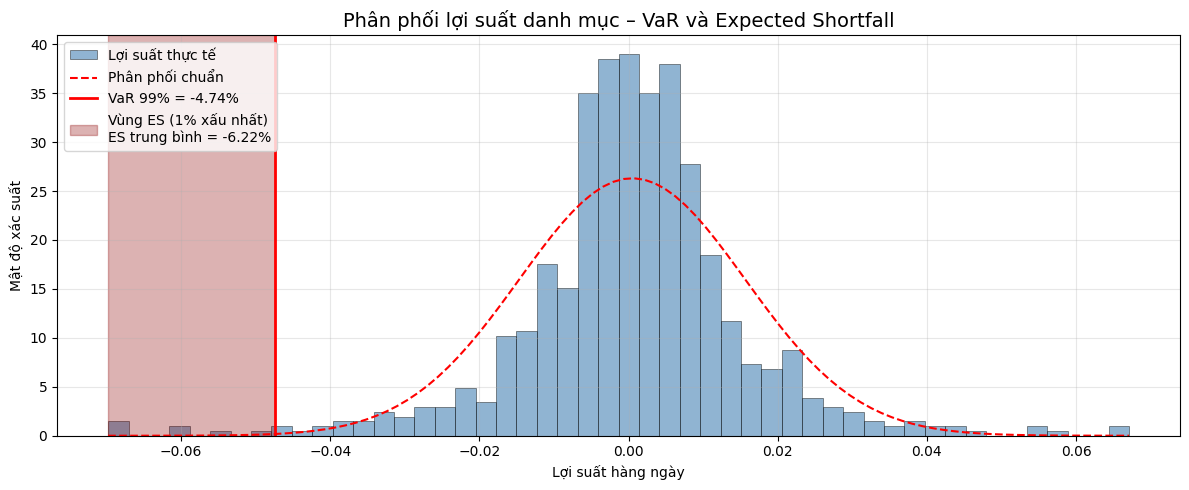

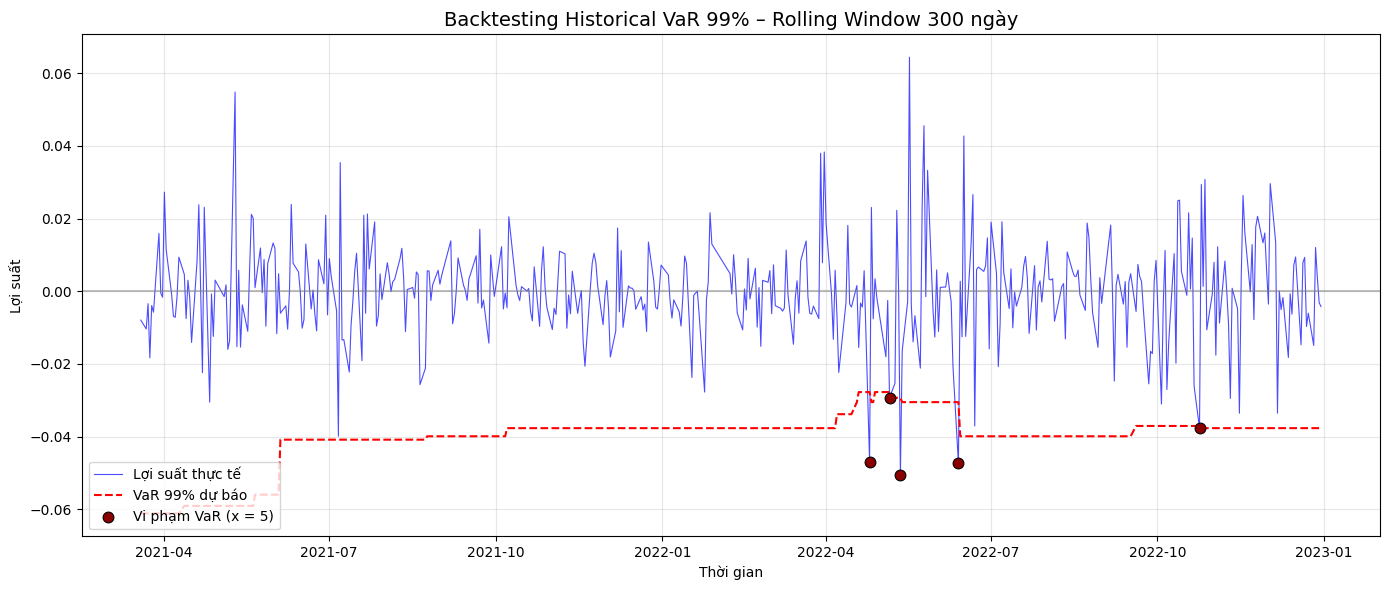

In [5]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd


# ========== 4. RETURN DISTRIBUTION & VAR / ES ==========
plt.figure(figsize=(12, 5))
# Vẽ histogram với density=True để thành mật độ xác suất
plt.hist(port_ret, bins=50, density=True, alpha=0.6, color='steelblue', 
         edgecolor='black', linewidth=0.5, label='Lợi suất thực tế')

# Vẽ đường phân phối chuẩn để so sánh (thể hiện "đuôi dày")
from scipy.stats import norm
mu, std = port_ret.mean(), port_ret.std()
x = np.linspace(port_ret.min(), port_ret.max(), 100)
plt.plot(x, norm.pdf(x, mu, std), 'r--', linewidth=1.5, label='Phân phối chuẩn')

# Đường VaR
var_return = sorted_port_ret[t]  # đã có từ code trước
plt.axvline(var_return, color='red', linestyle='-', linewidth=2, 
            label=f'VaR 99% = {var_return:.2%}')

# Tô vùng ES (các return nhỏ hơn VaR)
tail_returns = sorted_port_ret[:t]
plt.axvspan(port_ret.min(), var_return, alpha=0.3, color='darkred', 
            label=f'Vùng ES (1% xấu nhất)\nES trung bình = {tail_returns.mean():.2%}')

plt.title('Phân phối lợi suất danh mục – VaR và Expected Shortfall', fontsize=14)
plt.xlabel('Lợi suất hàng ngày')
plt.ylabel('Mật độ xác suất')
plt.legend(loc='upper left')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# ========== 5. BACKTESTING VISUALIZATION ==========
plt.figure(figsize=(14, 6))
# Vẽ lợi suất thực tế
plt.plot(backtest_df.index, backtest_df['Realized_Return'], 
         color='blue', alpha=0.7, linewidth=0.8, label='Lợi suất thực tế')
# Vẽ VaR dự báo
plt.plot(backtest_df.index, backtest_df['VaR_Return'], 
         color='red', linestyle='--', linewidth=1.5, label='VaR 99% dự báo')

# Đánh dấu các vi phạm
violations_df = backtest_df[backtest_df['Violation']]
plt.scatter(violations_df.index, violations_df['Realized_Return'], 
            color='darkred', s=60, marker='o', zorder=5, 
            edgecolors='black', linewidth=0.8, label=f'Vi phạm VaR (x = {len(violations_df)})')

plt.title('Backtesting Historical VaR 99% – Rolling Window 300 ngày', fontsize=14)
plt.xlabel('Thời gian')
plt.ylabel('Lợi suất')
plt.axhline(0, color='gray', linestyle='-', alpha=0.5)
plt.legend(loc='lower left')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()